# A Hovmöller diagram

A Hovmöller plot collapses one space dimension and keeps time, which makes
it the natural next step once zonal means work. It is also where picking the
right corner of the pyramid stops being an optimisation and starts being the
difference between a figure and a coffee break.

*The figure is saved with this notebook. Run the cells in order, from the top, to compute it again. The same example on the web: [A Hovmöller diagram](https://waterpark.dkrz.de/docs/examples/06_hovmoeller/).*

## Pick the frequency before the level

The hub is a pyramid in time as well as in space. The same ERA5 data is
published hourly, daily and monthly, and this figure has about five
hundred pixels along its time axis covering four decades. Monthly is
already finer than the plot can show.

Reading the hourly store and averaging it down would move seven hundred
times the bytes to draw exactly the same picture.

In [ ]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

URL = "s3://reanalysis/healpix/era5/P1M/level_4.zarr"
S3 = {"anon": True, "endpoint_url": "https://s3.waterpark.dkrz.de"}

ds = xr.open_zarr(URL, storage_options=S3, chunks=None)
level = ds.attrs["healpix_level"]

field = ds["tas"].sel(time=slice("1980", "2024"))
print(f"{field.sizes['time']} months x {field.sizes['cell']} cells, "
      f"{field.nbytes / 1e6:.0f} MB")

Level 4 for the same reason: a zonal mean has no longitudinal detail left
in it, and 63 rings is already more than the figure resolves vertically.
The level in the URL and the frequency in the URL are two independent
knobs, and both should be turned down to whatever the question actually
needs.

## Zonal means, by ring

In [ ]:
latitude = ds["latitude"].values
_, rings = np.unique(np.round(latitude, 8), return_inverse=True)

hov = field.assign_coords(ring=("cell", rings)).groupby("ring").mean().load()
ring_lat = np.array([latitude[rings == r][0] for r in range(rings.max() + 1)])

print(f"{hov.sizes['time']} months x {hov.sizes['ring']} rings")

## The rings are not evenly spaced

This matters here in a way it did not in the line plot. Plotting against
the ring *index* would stretch the poles and squash the tropics, because
HEALPix spaces its rings so that every cell has the same area, which in
the equatorial belt means evenly in the sine of latitude rather than in
latitude itself.

So give `pcolormesh` real latitude edges. Midpoints between neighbouring
rings are close enough for a figure and honest about what they are.

In [ ]:
lat_edges = np.concatenate([
    [-90.0], 0.5 * (ring_lat[1:] + ring_lat[:-1]), [90.0],
])

# `shading="flat"` wants edges on both axes, so the time axis needs one more
# entry than there are months: the closing edge of the last one.
times = hov["time"].values
time_edges = np.append(times, times[-1] + (times[-1] - times[-2]))

spacing = np.diff(ring_lat)
print(f"ring spacing: {spacing.min():.2f} deg at the equator, "
      f"{spacing.max():.2f} deg near the pole")

## The plot

Two panels: the field itself, which is dominated by the seasonal cycle,
and the same field with each month's 1980-2009 climatology removed, which
is where anything else lives.

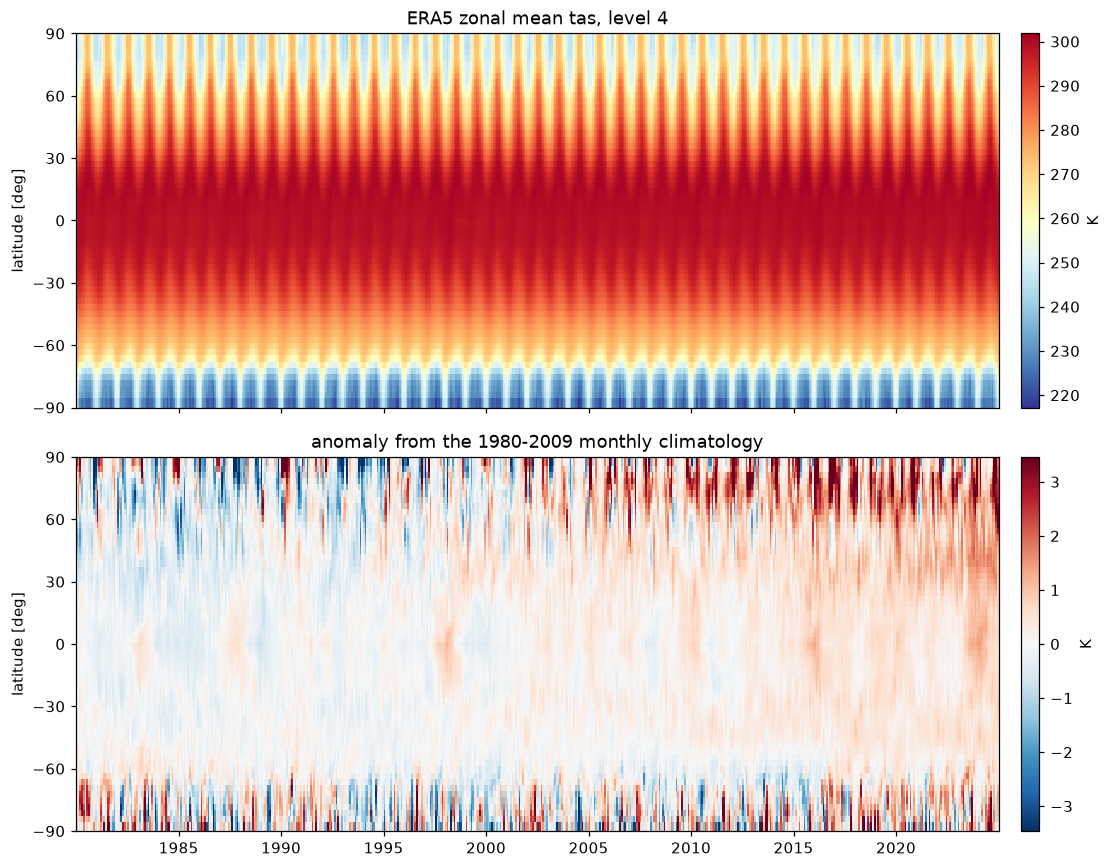

In [ ]:
climatology = hov.sel(time=slice("1980", "2009")).groupby("time.month").mean()
anomaly = hov.groupby("time.month") - climatology

fig, (ax_raw, ax_anom) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

mesh = ax_raw.pcolormesh(time_edges, lat_edges,
                         hov.transpose("ring", "time").values,
                         cmap="RdYlBu_r", shading="flat")
ax_raw.set_ylabel("latitude [deg]")
ax_raw.set_yticks(np.arange(-90, 91, 30))
ax_raw.set_title(f"ERA5 zonal mean tas, level {level}")
fig.colorbar(mesh, ax=ax_raw, pad=0.02, label="K")

span = float(np.nanpercentile(np.abs(anomaly.values), 99))
mesh = ax_anom.pcolormesh(time_edges, lat_edges,
                          anomaly.transpose("ring", "time").values,
                          cmap="RdBu_r", vmin=-span, vmax=span, shading="flat")
ax_anom.set_ylabel("latitude [deg]")
ax_anom.set_yticks(np.arange(-90, 91, 30))
ax_anom.set_title("anomaly from the 1980-2009 monthly climatology")
ax_anom.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.colorbar(mesh, ax=ax_anom, pad=0.02, label="K")

fig.tight_layout()
fig.savefig("06_hovmoeller.png", dpi=110, bbox_inches="tight", facecolor="white")
plt.show()

## What to read off it

The top panel is the seasonal cycle: large and antisymmetric in the
extratropics, small in the tropics, and larger in the northern hemisphere
than the southern one, which is the land-ocean contrast showing up as
thermal inertia. None of that is new, and that is the point. It is a check
that the pipeline is telling the truth before you point it at something
you do not already know the answer to.

The bottom panel is where the seasonal cycle has been taken out, and the
warming is visible as the red shifting rightwards, strongest at the
northern high latitudes. Whether you call that Arctic amplification or an
artefact of the reanalysis' changing observing system over four decades is
a question this figure cannot answer, and a good reason to be careful with
trends drawn from it.

Swapping `ring` for a longitude bin from the
[meridional mean](https://waterpark.dkrz.de/docs/examples/05_meridional_mean/) gives the tropical Hovmöller that
convection people actually want, with the same twenty lines.